In [1]:
from pathlib import Path
import os
import sys
import platform
import json
import time
import random
import shutil

BASE = Path("/home/jovyan")
DATA = BASE / "data"
TRAIN_ROOT = DATA / "TrainingData" / "TrainingData"
TEST_ROOT = DATA / "TestData" / "TestData"

OUT = BASE / "outputs"
FIGS = OUT / "figures"
LOGS = OUT / "logs"
RESULTS = OUT / "results"
REPORT = BASE / "report"

for p in [FIGS, LOGS, RESULTS, REPORT]:
    p.mkdir(parents=True, exist_ok=True)

print("Project folder:", BASE)
print("Training data:", TRAIN_ROOT)
print("Test data:", TEST_ROOT)
print("Python:", sys.version)
print("Platform:", platform.platform())

import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("CUDA is not available. Stop here. Restart kernel or fix PyTorch before training.")

Project folder: /home/jovyan
Training data: /home/jovyan/data/TrainingData/TrainingData
Test data: /home/jovyan/data/TestData/TestData
Python: 3.11.7 | packaged by conda-forge | (main, Dec 23 2023, 14:43:09) [GCC 12.3.0]
Platform: Linux-6.7.4-200.fc39.x86_64-x86_64-with-glibc2.35
Torch version: 2.3.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: NVIDIA A40


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.notebook import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda"

# Strong but safe for MRBrainS13 scan shape.
PATCH_SIZE = (64, 64, 32)
BATCH_SIZE = 1
LR = 1e-4
BASE_CHANNELS = 16
NUM_CLASSES = 4
NUM_WORKERS = 0

# Main full pipeline settings.
EPOCHS_LOOCV = 20
PATCHES_PER_SUBJECT = 40

# Small baseline comparison required for model-improvement evidence.
EPOCHS_ABLATION = 5
PATCHES_PER_SUBJECT_ABLATION = 30

# Final model for 15-subject test generalisation check.
EPOCHS_FINAL = 20

print("Device:", DEVICE)
print("Patch size:", PATCH_SIZE)
print("Classes: 0 background, 1 CSF, 2 gray matter, 3 white matter")

Device: cuda
Patch size: (64, 64, 32)
Classes: 0 background, 1 CSF, 2 gray matter, 3 white matter


In [3]:
for sid in ["1", "2", "3", "4", "5"]:
    subject_dir = TRAIN_ROOT / sid
    assert (subject_dir / "T1.nii").exists(), subject_dir
    assert (subject_dir / "T1_IR.nii").exists(), subject_dir
    assert (subject_dir / "T2_FLAIR.nii").exists(), subject_dir
    assert (subject_dir / "LabelsForTraining.nii").exists(), subject_dir
    assert (subject_dir / "LabelsForTesting.nii").exists(), subject_dir

for sid in [str(i) for i in range(1, 16)]:
    subject_dir = TEST_ROOT / sid
    assert (subject_dir / "T1.nii").exists(), subject_dir
    assert (subject_dir / "T1_IR.nii").exists(), subject_dir
    assert (subject_dir / "T2_FLAIR.nii").exists(), subject_dir
    assert (subject_dir / "LabelsForTesting.nii").exists(), subject_dir

print("All expected training and test files found.")

subjects = []

for sid in ["1", "2", "3", "4", "5"]:
    subject_dir = TRAIN_ROOT / sid

    subjects.append({
        "id": f"train_{sid}",
        "images": [
            str(subject_dir / "T1.nii"),
            str(subject_dir / "T1_IR.nii"),
            str(subject_dir / "T2_FLAIR.nii"),
        ],
        "label": str(subject_dir / "LabelsForTesting.nii"),
        "detailed_label": str(subject_dir / "LabelsForTraining.nii"),
        "label_type": "coarse_4class",
    })

test_subjects = []

for sid in [str(i) for i in range(1, 16)]:
    subject_dir = TEST_ROOT / sid

    test_subjects.append({
        "id": f"test_{sid}",
        "images": [
            str(subject_dir / "T1.nii"),
            str(subject_dir / "T1_IR.nii"),
            str(subject_dir / "T2_FLAIR.nii"),
        ],
        "label": str(subject_dir / "LabelsForTesting.nii"),
        "label_type": "coarse_4class",
    })

print("Training subjects:")
for s in subjects:
    print(s["id"], s["label"])

print("\nTest subjects:")
for s in test_subjects:
    print(s["id"], s["label"])

All expected training and test files found.
Training subjects:
train_1 /home/jovyan/data/TrainingData/TrainingData/1/LabelsForTesting.nii
train_2 /home/jovyan/data/TrainingData/TrainingData/2/LabelsForTesting.nii
train_3 /home/jovyan/data/TrainingData/TrainingData/3/LabelsForTesting.nii
train_4 /home/jovyan/data/TrainingData/TrainingData/4/LabelsForTesting.nii
train_5 /home/jovyan/data/TrainingData/TrainingData/5/LabelsForTesting.nii

Test subjects:
test_1 /home/jovyan/data/TestData/TestData/1/LabelsForTesting.nii
test_2 /home/jovyan/data/TestData/TestData/2/LabelsForTesting.nii
test_3 /home/jovyan/data/TestData/TestData/3/LabelsForTesting.nii
test_4 /home/jovyan/data/TestData/TestData/4/LabelsForTesting.nii
test_5 /home/jovyan/data/TestData/TestData/5/LabelsForTesting.nii
test_6 /home/jovyan/data/TestData/TestData/6/LabelsForTesting.nii
test_7 /home/jovyan/data/TestData/TestData/7/LabelsForTesting.nii
test_8 /home/jovyan/data/TestData/TestData/8/LabelsForTesting.nii
test_9 /home/jovya

In [4]:
def load_nifti(path):
    return nib.load(str(path)).get_fdata().astype(np.float32)


def normalise_image(x):
    x = x.astype(np.float32)
    mask = x != 0

    if mask.sum() > 100:
        mean = x[mask].mean()
        std = x[mask].std()
    else:
        mean = x.mean()
        std = x.std()

    if std < 1e-6:
        std = 1.0

    return ((x - mean) / std).astype(np.float32)


def load_subject(subject):
    channels = []

    for image_path in subject["images"]:
        x = load_nifti(image_path)
        x = normalise_image(x)
        channels.append(x)

    shapes = np.array([c.shape for c in channels])
    min_shape = tuple(shapes.min(axis=0).astype(int))

    channels = [
        c[:min_shape[0], :min_shape[1], :min_shape[2]]
        for c in channels
    ]

    x = np.stack(channels, axis=0).astype(np.float32)

    y = load_nifti(subject["label"]).astype(np.int64)
    y = y[:min_shape[0], :min_shape[1], :min_shape[2]]

    return x, y


def load_detailed_label(subject):
    y = load_nifti(subject["detailed_label"]).astype(np.int64)
    return y


# Check labels.
label_rows = []

for s in subjects:
    _, y_coarse = load_subject(s)
    y_detail = load_detailed_label(s)

    print(s["id"])
    print("  coarse labels:", np.unique(y_coarse))
    print("  detailed labels:", np.unique(y_detail))

    for lab, count in zip(*np.unique(y_coarse, return_counts=True)):
        label_rows.append({
            "subject": s["id"],
            "label_type": "coarse_4class",
            "label": int(lab),
            "voxel_count": int(count),
        })

    for lab, count in zip(*np.unique(y_detail, return_counts=True)):
        label_rows.append({
            "subject": s["id"],
            "label_type": "detailed_8class",
            "label": int(lab),
            "voxel_count": int(count),
        })

df_label_dist = pd.DataFrame(label_rows)
df_label_dist.to_csv(RESULTS / "label_distribution_detailed_and_coarse.csv", index=False)

display(df_label_dist.head())


train_1
  coarse labels: [0 1 2 3]
  detailed labels: [0 1 2 3 4 5 6 7 8]
train_2
  coarse labels: [0 1 2 3]
  detailed labels: [0 1 2 3 4 5 6 7 8]
train_3
  coarse labels: [0 1 2 3]
  detailed labels: [0 1 2 3 4 5 6 7 8]
train_4
  coarse labels: [0 1 2 3]
  detailed labels: [0 1 2 3 4 5 6 7 8]
train_5
  coarse labels: [0 1 2 3]
  detailed labels: [0 1 2 3 4 5 6 7 8]


,subject,label_type,label,voxel_count
0,train_1,coarse_4class,0,2308268
1,train_1,coarse_4class,1,164075
2,train_1,coarse_4class,2,167873
3,train_1,coarse_4class,3,124584
4,train_1,detailed_8class,0,2261444


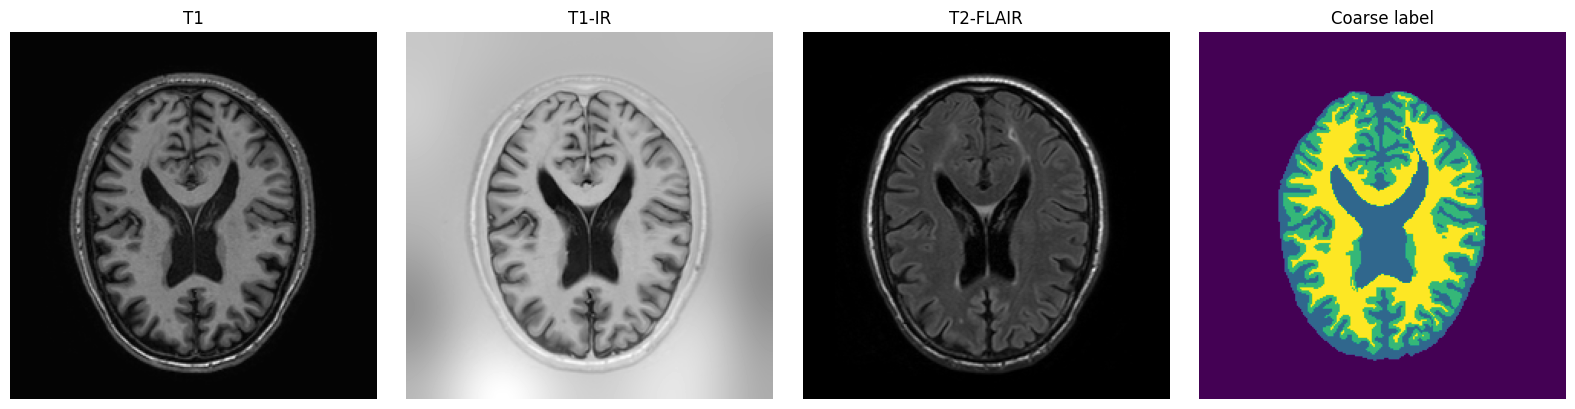

In [5]:
# Dataset example visualisation.
x0, y0 = load_subject(subjects[0])
z = x0.shape[3] // 2

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(x0[0, :, :, z].T, cmap="gray", origin="lower")
plt.title("T1")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(x0[1, :, :, z].T, cmap="gray", origin="lower")
plt.title("T1-IR")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(x0[2, :, :, z].T, cmap="gray", origin="lower")
plt.title("T2-FLAIR")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(y0[:, :, z].T, origin="lower")
plt.title("Coarse label")
plt.axis("off")

plt.tight_layout()
plt.savefig(FIGS / "dataset_example_modalities_and_label.png", dpi=200)
plt.show()

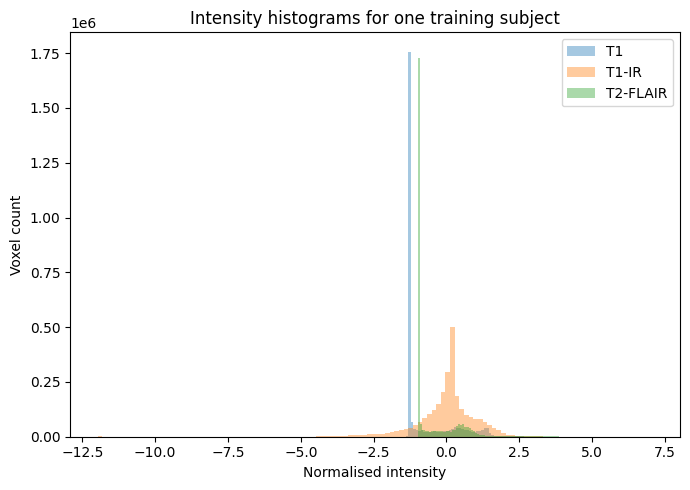

In [6]:
# Intensity histogram.
plt.figure(figsize=(7, 5))

for i, name in enumerate(["T1", "T1-IR", "T2-FLAIR"]):
    vals = x0[i][x0[i] != 0]
    plt.hist(vals.flatten(), bins=100, alpha=0.4, label=name)

plt.xlabel("Normalised intensity")
plt.ylabel("Voxel count")
plt.title("Intensity histograms for one training subject")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS / "intensity_histograms.png", dpi=200)
plt.show()

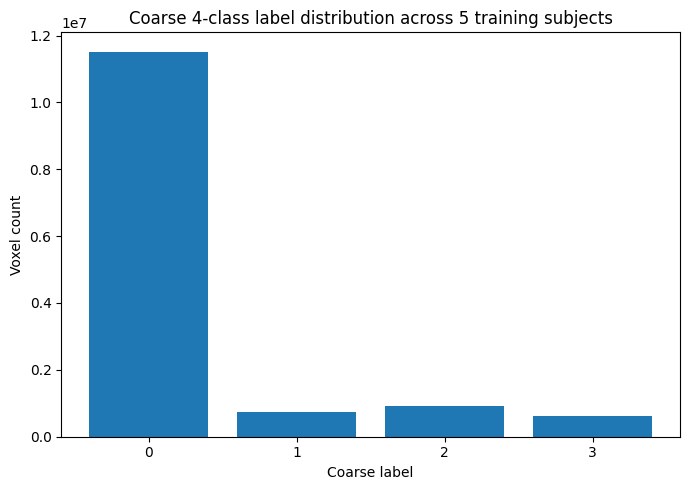

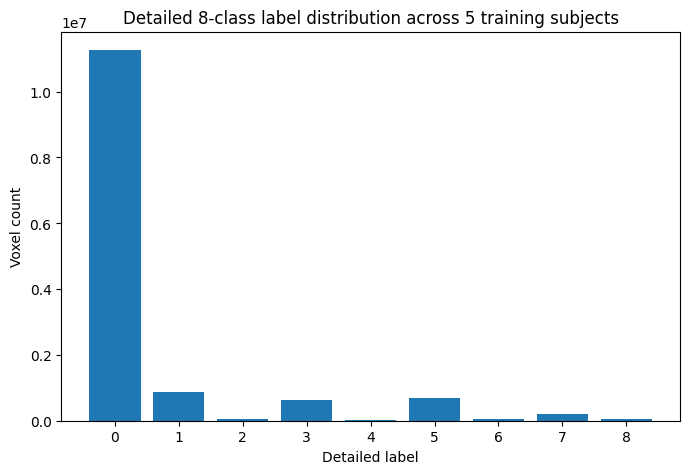

In [7]:
# Coarse label distribution.
coarse = df_label_dist[df_label_dist["label_type"] == "coarse_4class"]
coarse_sum = coarse.groupby("label")["voxel_count"].sum()

plt.figure(figsize=(7, 5))
plt.bar(coarse_sum.index.astype(str), coarse_sum.values)
plt.xlabel("Coarse label")
plt.ylabel("Voxel count")
plt.title("Coarse 4-class label distribution across 5 training subjects")
plt.tight_layout()
plt.savefig(FIGS / "coarse_label_distribution.png", dpi=200)
plt.show()

# Detailed label distribution.
detail = df_label_dist[df_label_dist["label_type"] == "detailed_8class"]
detail_sum = detail.groupby("label")["voxel_count"].sum()

plt.figure(figsize=(7, 5))
plt.bar(detail_sum.index.astype(str), detail_sum.values)
plt.xlabel("Detailed label")
plt.ylabel("Voxel count")
plt.title("Detailed 8-class label distribution across 5 training subjects")
plt.tight_layout()
plt.savefig(FIGS / "detailed_label_distribution.png", dpi=200)
plt.show()

In [15]:
class PatchDataset(Dataset):
    def __init__(
        self,
        subjects,
        patches_per_subject,
        patch_size,
        augment,
        foreground_sampling,
    ):
        self.subjects = subjects
        self.patches_per_subject = patches_per_subject
        self.patch_size = patch_size
        self.augment = augment
        self.foreground_sampling = foreground_sampling

        self.data = []

        for s in subjects:
            x, y = load_subject(s)

            if not np.all(np.isin(np.unique(y), np.arange(NUM_CLASSES))):
                raise ValueError(f"Unexpected labels in {s['id']}: {np.unique(y)}")

            self.data.append({
                "id": s["id"],
                "image": x,
                "label": y,
            })

            print("Loaded", s["id"], "image", x.shape, "label", y.shape, "labels", np.unique(y))

        self.length = len(self.data) * patches_per_subject

    def __len__(self):
        return self.length

    def _crop_coords(self, y):
        px, py, pz = self.patch_size
        sx, sy, sz = y.shape

        if sx < px or sy < py or sz < pz:
            raise RuntimeError(f"Volume {y.shape} smaller than patch {self.patch_size}")

        if self.foreground_sampling and random.random() < 0.7:
            fg = np.argwhere(y > 0)

            if len(fg) > 0:
                cx, cy, cz = fg[random.randint(0, len(fg) - 1)]

                x0 = int(np.clip(cx - px // 2, 0, sx - px))
                y0 = int(np.clip(cy - py // 2, 0, sy - py))
                z0 = int(np.clip(cz - pz // 2, 0, sz - pz))

                return x0, y0, z0

        x0 = random.randint(0, sx - px)
        y0 = random.randint(0, sy - py)
        z0 = random.randint(0, sz - pz)

        return x0, y0, z0

    def _augment(self, x, y):
        # x: C, X, Y, Z
        # y: X, Y, Z

        for axis in [1, 2, 3]:
            if random.random() < 0.5:
                x = np.flip(x, axis=axis).copy()
                y = np.flip(y, axis=axis - 1).copy()

        if random.random() < 0.3:
            x = x + np.random.normal(0, 0.05, size=x.shape).astype(np.float32)

        if random.random() < 0.3:
            scale = np.random.uniform(0.9, 1.1)
            shift = np.random.uniform(-0.1, 0.1)
            x = x * scale + shift

        return x.astype(np.float32), y.astype(np.int64)

    def __getitem__(self, idx):
        item = self.data[idx % len(self.data)]
        x = item["image"]
        y = item["label"]

        px, py, pz = self.patch_size
        x0, y0, z0 = self._crop_coords(y)

        xp = x[:, x0:x0+px, y0:y0+py, z0:z0+pz]
        yp = y[x0:x0+px, y0:y0+py, z0:z0+pz]

        if self.augment:
            xp, yp = self._augment(xp, yp)

        return torch.from_numpy(xp).float(), torch.from_numpy(yp).long()

In [16]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.LeakyReLU(inplace=True),

            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.LeakyReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet3D(nn.Module):
    def __init__(self, in_channels=3, num_classes=4, base_ch=16):
        super().__init__()

        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)
        self.pool3 = nn.MaxPool3d(2)

        self.bottleneck = ConvBlock(base_ch * 4, base_ch * 8)

        self.up3 = nn.ConvTranspose3d(base_ch * 8, base_ch * 4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(base_ch * 8, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_ch * 2, base_ch)

        self.out = nn.Conv3d(base_ch, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)

        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [17]:
def soft_dice_loss(logits, targets, eps=1e-6):
    probs = torch.softmax(logits, dim=1)

    targets_1h = F.one_hot(targets, NUM_CLASSES)
    targets_1h = targets_1h.permute(0, 4, 1, 2, 3).float()

    dims = (0, 2, 3, 4)

    intersection = torch.sum(probs * targets_1h, dims)
    denominator = torch.sum(probs + targets_1h, dims)

    dice = (2 * intersection + eps) / (denominator + eps)

    # Exclude background from optimisation average.
    dice = dice[1:]

    return 1 - dice.mean()


def get_loss(logits, targets, loss_mode):
    if loss_mode == "dice":
        return soft_dice_loss(logits, targets)

    if loss_mode == "dice_ce":
        return soft_dice_loss(logits, targets) + F.cross_entropy(logits, targets)

    raise ValueError(loss_mode)


def dice_per_class(pred, target, num_classes=4):
    scores = []

    for c in range(num_classes):
        p = pred == c
        t = target == c

        inter = np.logical_and(p, t).sum()
        denom = p.sum() + t.sum()

        if denom == 0:
            scores.append(np.nan)
        else:
            scores.append(float(2.0 * inter / denom))

    return scores


def mean_foreground_dice(scores):
    fg = [s for s in scores[1:] if not np.isnan(s)]
    return float(np.mean(fg)) if len(fg) else np.nan

In [18]:
def pad_to_patch(x, patch_size):
    # x shape: C, X, Y, Z
    c, sx, sy, sz = x.shape
    px, py, pz = patch_size

    pad_x = max(0, px - sx)
    pad_y = max(0, py - sy)
    pad_z = max(0, pz - sz)

    if pad_x == 0 and pad_y == 0 and pad_z == 0:
        return x, (sx, sy, sz)

    padded = np.pad(
        x,
        pad_width=((0, 0), (0, pad_x), (0, pad_y), (0, pad_z)),
        mode="constant",
        constant_values=0,
    )

    return padded, (sx, sy, sz)


def make_starts(size, patch, stride):
    if size <= patch:
        return [0]

    starts = list(range(0, size - patch + 1, stride))

    if starts[-1] != size - patch:
        starts.append(size - patch)

    return starts


def sliding_window_predict(model, x, patch_size=PATCH_SIZE, overlap=0.5):
    model.eval()

    x_pad, original_shape = pad_to_patch(x, patch_size)
    c, sx, sy, sz = x_pad.shape

    px, py, pz = patch_size

    stride_x = max(1, int(px * (1 - overlap)))
    stride_y = max(1, int(py * (1 - overlap)))
    stride_z = max(1, int(pz * (1 - overlap)))

    xs = make_starts(sx, px, stride_x)
    ys = make_starts(sy, py, stride_y)
    zs = make_starts(sz, pz, stride_z)

    prob_sum = np.zeros((NUM_CLASSES, sx, sy, sz), dtype=np.float32)
    count = np.zeros((1, sx, sy, sz), dtype=np.float32)

    with torch.no_grad():
        for xi in xs:
            for yi in ys:
                for zi in zs:
                    patch = x_pad[:, xi:xi+px, yi:yi+py, zi:zi+pz]
                    patch_t = torch.from_numpy(patch[None]).float().to(DEVICE)

                    logits = model(patch_t)
                    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

                    prob_sum[:, xi:xi+px, yi:yi+py, zi:zi+pz] += probs
                    count[:, xi:xi+px, yi:yi+py, zi:zi+pz] += 1

    prob_avg = prob_sum / np.maximum(count, 1e-6)
    pred = np.argmax(prob_avg, axis=0).astype(np.int64)

    ox, oy, oz = original_shape
    pred = pred[:ox, :oy, :oz]

    return pred

In [19]:
def save_prediction_figure(x, y, pred, out_path, title):
    error = (pred != y).astype(np.float32)

    # choose slice with most foreground
    fg_per_slice = [(y[:, :, zi] > 0).sum() for zi in range(y.shape[2])]
    z = int(np.argmax(fg_per_slice))

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(x[0, :, :, z].T, cmap="gray", origin="lower")
    plt.title("T1")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(y[:, :, z].T, origin="lower", vmin=0, vmax=NUM_CLASSES-1)
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred[:, :, z].T, origin="lower", vmin=0, vmax=NUM_CLASSES-1)
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(error[:, :, z].T, origin="lower")
    plt.title("Error map")
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


def evaluate_model_on_subjects(model, eval_subjects, split_name, save_figures=True):
    rows = []

    for subject in eval_subjects:
        x, y = load_subject(subject)
        pred = sliding_window_predict(model, x)

        scores = dice_per_class(pred, y, NUM_CLASSES)

        row = {
            "split": split_name,
            "subject": subject["id"],
            "dice_background": scores[0],
            "dice_csf": scores[1],
            "dice_gray_matter": scores[2],
            "dice_white_matter": scores[3],
            "mean_foreground_dice": mean_foreground_dice(scores),
        }

        rows.append(row)

        if save_figures:
            save_prediction_figure(
                x,
                y,
                pred,
                FIGS / f"{split_name}_{subject['id']}_prediction.png",
                f"{split_name} {subject['id']}"
            )

    return pd.DataFrame(rows)

In [20]:
def train_model(
    run_name,
    train_subjects,
    epochs,
    patches_per_subject,
    loss_mode,
    augment,
    foreground_sampling,
):
    print("\n" + "=" * 100)
    print("RUN:", run_name)
    print("Train subjects:", [s["id"] for s in train_subjects])
    print("Epochs:", epochs)
    print("Loss:", loss_mode)
    print("Augment:", augment)
    print("Foreground sampling:", foreground_sampling)
    print("=" * 100)

    log_path = LOGS / f"{run_name}_train_log.txt"

    with open(log_path, "w") as f:
        f.write(f"run_name: {run_name}\n")
        f.write(f"train_subjects: {[s['id'] for s in train_subjects]}\n")
        f.write(f"epochs: {epochs}\n")
        f.write(f"patches_per_subject: {patches_per_subject}\n")
        f.write(f"patch_size: {PATCH_SIZE}\n")
        f.write(f"batch_size: {BATCH_SIZE}\n")
        f.write(f"base_channels: {BASE_CHANNELS}\n")
        f.write(f"learning_rate: {LR}\n")
        f.write(f"loss_mode: {loss_mode}\n")
        f.write(f"augment: {augment}\n")
        f.write(f"foreground_sampling: {foreground_sampling}\n")
        f.write(f"device: {DEVICE}\n")
        f.write(f"gpu: {torch.cuda.get_device_name(0)}\n\n")

    ds = PatchDataset(
        train_subjects,
        patches_per_subject=patches_per_subject,
        patch_size=PATCH_SIZE,
        augment=augment,
        foreground_sampling=foreground_sampling,
    )

    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    model = UNet3D(
        in_channels=3,
        num_classes=NUM_CLASSES,
        base_ch=BASE_CHANNELS,
    ).to(DEVICE)

    optimiser = torch.optim.Adam(model.parameters(), lr=LR)

    losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        pbar = tqdm(loader, desc=f"{run_name} epoch {epoch}/{epochs}")

        for x, y in pbar:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimiser.zero_grad(set_to_none=True)

            logits = model(x)
            loss = get_loss(logits, y, loss_mode)

            loss.backward()
            optimiser.step()

            loss_value = float(loss.item())
            epoch_losses.append(loss_value)
            pbar.set_postfix(loss=f"{loss_value:.4f}")

        mean_loss = float(np.mean(epoch_losses))
        losses.append(mean_loss)

        msg = f"epoch {epoch}/{epochs}, train_loss={mean_loss:.6f}"
        print(msg)

        with open(log_path, "a") as f:
            f.write(msg + "\n")

        # Internal checkpoint only. Do not submit.
        torch.save(
            {
                "run_name": run_name,
                "epoch": epoch,
                "model_state": model.state_dict(),
                "settings": {
                    "PATCH_SIZE": PATCH_SIZE,
                    "BASE_CHANNELS": BASE_CHANNELS,
                    "NUM_CLASSES": NUM_CLASSES,
                    "loss_mode": loss_mode,
                    "augment": augment,
                    "foreground_sampling": foreground_sampling,
                }
            },
            RESULTS / f"{run_name}_checkpoint_INTERNAL_DO_NOT_SUBMIT.pth"
        )

    loss_df = pd.DataFrame({
        "run_name": run_name,
        "epoch": list(range(1, epochs + 1)),
        "train_loss": losses,
    })

    loss_df.to_csv(RESULTS / f"{run_name}_training_losses.csv", index=False)

    plt.figure(figsize=(7, 5))
    plt.plot(loss_df["epoch"], loss_df["train_loss"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Training loss: {run_name}")
    plt.tight_layout()
    plt.savefig(FIGS / f"{run_name}_training_loss.png", dpi=200)
    plt.close()

    return model, loss_df

In [22]:
from tqdm import tqdm
print("Using standard tqdm progress bar.")

# Fold 1 only: baseline vs improved comparison.
val_subject = subjects[0]
train_subjects = subjects[1:]

baseline_model, baseline_loss = train_model(
    run_name="ablation_baseline_dice_no_aug_fold1",
    train_subjects=train_subjects,
    epochs=EPOCHS_ABLATION,
    patches_per_subject=PATCHES_PER_SUBJECT_ABLATION,
    loss_mode="dice",
    augment=False,
    foreground_sampling=True,
)

baseline_eval = evaluate_model_on_subjects(
    baseline_model,
    [val_subject],
    split_name="ablation_baseline_fold1",
    save_figures=True,
)

display(baseline_eval)
baseline_eval.to_csv(RESULTS / "ablation_baseline_fold1_results.csv", index=False)

Using standard tqdm progress bar.

RUN: ablation_baseline_dice_no_aug_fold1
Train subjects: ['train_2', 'train_3', 'train_4', 'train_5']
Epochs: 5
Loss: dice
Augment: False
Foreground sampling: True
Loaded train_2 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_3 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_4 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_5 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]




ablation_baseline_dice_no_aug_fold1 epoch 1/5:   0%|          | 0/120 [00:00<?, ?it/s]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=0.8298]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:   1%|          | 1/120 [00:00<01:20,  1.47it/s, loss=0.8298]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:   1%|          | 1/120 [00:00<01:20,  1.47it/s, loss=0.7347]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:   2%|▏         | 2/120 [00:00<00:40,  2.91it/s, loss=0.7347]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:   2%|▏         | 2/120 [00:00<00:40,  2.91it/s, loss=0.9674]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:   2%|▎         | 3/120 [00:00<00:32,  3.58it/s, loss=0.9674]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:   2%|▎         | 3/120 [00:01<00:32,  3.58it/s, loss=0.7563]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:   2%|▎         | 3/120 [00:01<00:32,  3.58it/s, loss=0.8314]

ablation_baseline_dice_no_aug_fold1 epoch 1/5:

epoch 1/5, train_loss=0.656872




ablation_baseline_dice_no_aug_fold1 epoch 2/5:   0%|          | 0/120 [00:00<?, ?it/s]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=0.5023]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=0.7477]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   2%|▏         | 2/120 [00:00<00:11, 10.26it/s, loss=0.7477]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   2%|▏         | 2/120 [00:00<00:11, 10.26it/s, loss=0.5418]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   2%|▏         | 2/120 [00:00<00:11, 10.26it/s, loss=0.6727]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   3%|▎         | 4/120 [00:00<00:15,  7.73it/s, loss=0.6727]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   3%|▎         | 4/120 [00:00<00:15,  7.73it/s, loss=0.4856]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   3%|▎         | 4/120 [00:00<00:15,  7.73it/s, loss=0.6552]

ablation_baseline_dice_no_aug_fold1 epoch 2/5:   5%|▌ 

epoch 2/5, train_loss=0.555467


...



ablation_baseline_dice_no_aug_fold1 epoch 4/5:   0%|          | 0/120 [00:00<?, ?it/s]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=0.8781]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=0.4031]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   2%|▏         | 2/120 [00:00<00:15,  7.76it/s, loss=0.4031]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   2%|▏         | 2/120 [00:00<00:15,  7.76it/s, loss=0.6967]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   2%|▎         | 3/120 [00:00<00:14,  8.22it/s, loss=0.6967]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   2%|▎         | 3/120 [00:00<00:14,  8.22it/s, loss=0.4070]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   2%|▎         | 3/120 [00:00<00:14,  8.22it/s, loss=0.9999]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   4%|▍         | 5/120 [00:00<00:12,  8.89it/s, loss=0.9999]

ablation_baseline_dice_no_aug_fold1 epoch 4/5:   4%|▍ 

epoch 4/5, train_loss=0.509614




ablation_baseline_dice_no_aug_fold1 epoch 5/5:   0%|          | 0/120 [00:00<?, ?it/s]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=0.6088]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=0.8787]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   2%|▏         | 2/120 [00:00<00:10, 11.36it/s, loss=0.8787]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   2%|▏         | 2/120 [00:00<00:10, 11.36it/s, loss=0.4404]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   2%|▏         | 2/120 [00:00<00:10, 11.36it/s, loss=0.4629]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   3%|▎         | 4/120 [00:00<00:14,  8.18it/s, loss=0.4629]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   3%|▎         | 4/120 [00:00<00:14,  8.18it/s, loss=0.3960]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   4%|▍         | 5/120 [00:00<00:15,  7.27it/s, loss=0.3960]

ablation_baseline_dice_no_aug_fold1 epoch 5/5:   4%|▍ 

epoch 5/5, train_loss=0.489975


,split,subject,dice_background,dice_csf,dice_gray_matter,dice_white_matter,mean_foreground_dice
0,ablation_baseline_fold1,train_1,0.299864,0.522888,0.249499,0.192811,0.321733


In [23]:
improved_model, improved_loss = train_model(
    run_name="ablation_improved_dice_ce_aug_fold1",
    train_subjects=train_subjects,
    epochs=EPOCHS_ABLATION,
    patches_per_subject=PATCHES_PER_SUBJECT_ABLATION,
    loss_mode="dice_ce",
    augment=True,
    foreground_sampling=True,
)

improved_eval = evaluate_model_on_subjects(
    improved_model,
    [val_subject],
    split_name="ablation_improved_fold1",
    save_figures=True,
)

display(improved_eval)
improved_eval.to_csv(RESULTS / "ablation_improved_fold1_results.csv", index=False)


RUN: ablation_improved_dice_ce_aug_fold1
Train subjects: ['train_2', 'train_3', 'train_4', 'train_5']
Epochs: 5
Loss: dice_ce
Augment: True
Foreground sampling: True
Loaded train_2 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_3 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_4 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_5 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]




ablation_improved_dice_ce_aug_fold1 epoch 1/5:   0%|          | 0/120 [00:00<?, ?it/s]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=2.1420]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=2.0641]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   2%|▏         | 2/120 [00:00<00:10, 10.77it/s, loss=2.0641]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   2%|▏         | 2/120 [00:00<00:10, 10.77it/s, loss=2.0761]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   2%|▏         | 2/120 [00:00<00:10, 10.77it/s, loss=2.0657]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   3%|▎         | 4/120 [00:00<00:14,  7.94it/s, loss=2.0657]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   3%|▎         | 4/120 [00:00<00:14,  7.94it/s, loss=2.0725]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   4%|▍         | 5/120 [00:00<00:16,  6.88it/s, loss=2.0725]

ablation_improved_dice_ce_aug_fold1 epoch 1/5:   4%|▍ 

epoch 1/5, train_loss=1.744965




ablation_improved_dice_ce_aug_fold1 epoch 2/5:   0%|          | 0/120 [00:00<?, ?it/s]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=1.7885]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:   1%|          | 1/120 [00:00<00:12,  9.88it/s, loss=1.7885]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:   1%|          | 1/120 [00:00<00:12,  9.88it/s, loss=1.4728]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:   1%|          | 1/120 [00:00<00:12,  9.88it/s, loss=1.4833]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:   2%|▎         | 3/120 [00:00<00:15,  7.52it/s, loss=1.4833]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:   2%|▎         | 3/120 [00:00<00:15,  7.52it/s, loss=1.4301]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:   3%|▎         | 4/120 [00:00<00:14,  8.21it/s, loss=1.4301]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:   3%|▎         | 4/120 [00:00<00:14,  8.21it/s, loss=1.4622]

ablation_improved_dice_ce_aug_fold1 epoch 2/5:

epoch 2/5, train_loss=1.510924


...



ablation_improved_dice_ce_aug_fold1 epoch 4/5:   0%|          | 0/120 [00:00<?, ?it/s]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=1.2974]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:   1%|          | 1/120 [00:00<00:13,  8.57it/s, loss=1.2974]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:   1%|          | 1/120 [00:00<00:13,  8.57it/s, loss=1.4772]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:   1%|          | 1/120 [00:00<00:13,  8.57it/s, loss=1.2500]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:   2%|▎         | 3/120 [00:00<00:16,  7.22it/s, loss=1.2500]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:   2%|▎         | 3/120 [00:00<00:16,  7.22it/s, loss=1.3575]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:   3%|▎         | 4/120 [00:00<00:14,  7.80it/s, loss=1.3575]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:   3%|▎         | 4/120 [00:00<00:14,  7.80it/s, loss=1.3493]

ablation_improved_dice_ce_aug_fold1 epoch 4/5:

epoch 4/5, train_loss=1.331291




ablation_improved_dice_ce_aug_fold1 epoch 5/5:   0%|          | 0/120 [00:00<?, ?it/s]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=1.4216]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   0%|          | 0/120 [00:00<?, ?it/s, loss=1.7763]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   2%|▏         | 2/120 [00:00<00:10, 10.83it/s, loss=1.7763]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   2%|▏         | 2/120 [00:00<00:10, 10.83it/s, loss=1.2045]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   2%|▏         | 2/120 [00:00<00:10, 10.83it/s, loss=1.4345]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   3%|▎         | 4/120 [00:00<00:14,  8.25it/s, loss=1.4345]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   3%|▎         | 4/120 [00:00<00:14,  8.25it/s, loss=1.2764]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   4%|▍         | 5/120 [00:00<00:13,  8.40it/s, loss=1.2764]

ablation_improved_dice_ce_aug_fold1 epoch 5/5:   4%|▍ 

epoch 5/5, train_loss=1.283686


,split,subject,dice_background,dice_csf,dice_gray_matter,dice_white_matter,mean_foreground_dice
0,ablation_improved_fold1,train_1,0.878276,0.595091,0.41803,0.747306,0.586809


,method,subject,dice_csf,dice_gray_matter,dice_white_matter,mean_foreground_dice
0,baseline_dice_no_aug,train_1,0.522888,0.249499,0.192811,0.321733
1,improved_dice_ce_aug,train_1,0.595091,0.418030,0.747306,0.586809


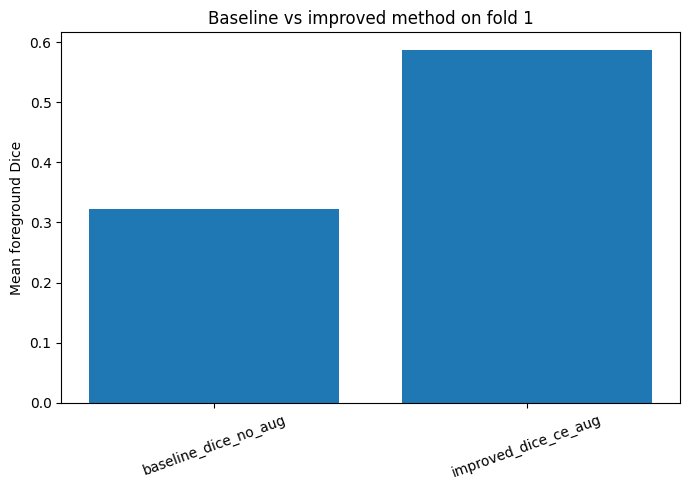

In [24]:
ablation_summary = pd.concat([
    baseline_eval.assign(method="baseline_dice_no_aug"),
    improved_eval.assign(method="improved_dice_ce_aug"),
], ignore_index=True)

ablation_summary = ablation_summary[
    [
        "method",
        "subject",
        "dice_csf",
        "dice_gray_matter",
        "dice_white_matter",
        "mean_foreground_dice",
    ]
]

display(ablation_summary)
ablation_summary.to_csv(RESULTS / "ablation_summary.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    ablation_summary["method"],
    ablation_summary["mean_foreground_dice"],
)
plt.ylabel("Mean foreground Dice")
plt.title("Baseline vs improved method on fold 1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGS / "ablation_baseline_vs_improved.png", dpi=200)
plt.show()

In [25]:
loocv_rows = []
all_loss_dfs = []

for fold_idx in range(5):
    val_subject = subjects[fold_idx]
    train_subjects = [s for i, s in enumerate(subjects) if i != fold_idx]

    run_name = f"loocv_fold_{fold_idx + 1}_improved"

    model, loss_df = train_model(
        run_name=run_name,
        train_subjects=train_subjects,
        epochs=EPOCHS_LOOCV,
        patches_per_subject=PATCHES_PER_SUBJECT,
        loss_mode="dice_ce",
        augment=True,
        foreground_sampling=True,
    )

    loss_df["fold"] = fold_idx + 1
    all_loss_dfs.append(loss_df)

    eval_df = evaluate_model_on_subjects(
        model,
        [val_subject],
        split_name=f"loocv_fold_{fold_idx + 1}",
        save_figures=True,
    )

    eval_df["fold"] = fold_idx + 1
    loocv_rows.append(eval_df)

    partial_df = pd.concat(loocv_rows, ignore_index=True)
    partial_df.to_csv(RESULTS / "loocv_results_partial.csv", index=False)

    display(eval_df)

loocv_results = pd.concat(loocv_rows, ignore_index=True)
loocv_losses = pd.concat(all_loss_dfs, ignore_index=True)

loocv_results.to_csv(RESULTS / "loocv_results.csv", index=False)
loocv_losses.to_csv(RESULTS / "loocv_training_losses.csv", index=False)

display(loocv_results)


RUN: loocv_fold_1_improved
Train subjects: ['train_2', 'train_3', 'train_4', 'train_5']
Epochs: 20
Loss: dice_ce
Augment: True
Foreground sampling: True
Loaded train_2 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_3 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_4 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_5 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]




loocv_fold_1_improved epoch 1/20:   0%|          | 0/160 [00:00<?, ?it/s]

loocv_fold_1_improved epoch 1/20:   0%|          | 0/160 [00:00<?, ?it/s, loss=2.1167]

loocv_fold_1_improved epoch 1/20:   1%|          | 1/160 [00:00<00:17,  8.89it/s, loss=2.1167]

loocv_fold_1_improved epoch 1/20:   1%|          | 1/160 [00:00<00:17,  8.89it/s, loss=2.0627]

loocv_fold_1_improved epoch 1/20:   1%|▏         | 2/160 [00:00<00:17,  9.20it/s, loss=2.0627]

loocv_fold_1_improved epoch 1/20:   1%|▏         | 2/160 [00:00<00:17,  9.20it/s, loss=2.0297]

loocv_fold_1_improved epoch 1/20:   2%|▏         | 3/160 [00:00<00:23,  6.76it/s, loss=2.0297]

loocv_fold_1_improved epoch 1/20:   2%|▏         | 3/160 [00:00<00:23,  6.76it/s, loss=2.0228]

loocv_fold_1_improved epoch 1/20:   2%|▎         | 4/160 [00:00<00:20,  7.65it/s, loss=2.0228]

loocv_fold_1_improved epoch 1/20:   2%|▎         | 4/160 [00:00<00:20,  7.65it/s, loss=2.0033]

loocv_fold_1_improved epoch 1/20:   3%|▎         | 5/160 [00:00<00:

epoch 1/20, train_loss=1.669708




loocv_fold_1_improved epoch 2/20:   0%|          | 0/160 [00:00<?, ?it/s]

loocv_fold_1_improved epoch 2/20:   0%|          | 0/160 [00:00<?, ?it/s, loss=1.5864]

loocv_fold_1_improved epoch 2/20:   0%|          | 0/160 [00:00<?, ?it/s, loss=2.0598]

loocv_fold_1_improved epoch 2/20:   1%|▏         | 2/160 [00:00<00:21,  7.28it/s, loss=2.0598]

loocv_fold_1_improved epoch 2/20:   1%|▏         | 2/160 [00:00<00:21,  7.28it/s, loss=1.6218]

loocv_fold_1_improved epoch 2/20:   2%|▏         | 3/160 [00:00<00:19,  8.03it/s, loss=1.6218]

loocv_fold_1_improved epoch 2/20:   2%|▏         | 3/160 [00:00<00:19,  8.03it/s, loss=1.3734]

loocv_fold_1_improved epoch 2/20:   2%|▎         | 4/160 [00:00<00:18,  8.58it/s, loss=1.3734]

loocv_fold_1_improved epoch 2/20:   2%|▎         | 4/160 [00:00<00:18,  8.58it/s, loss=1.4198]

loocv_fold_1_improved epoch 2/20:   3%|▎         | 5/160 [00:00<00:22,  7.01it/s, loss=1.4198]

loocv_fold_1_improved epoch 2/20:   3%|▎         | 5/160 [00:00<00:22,  7.0

epoch 2/20, train_loss=1.471064


...

epoch 19/20, train_loss=0.677379


loocv_fold_5_improved epoch 20/20: 100%|██████████| 160/160 [00:21<00:00,  7.52it/s, loss=0.7046]


epoch 20/20, train_loss=0.641997


,split,subject,dice_background,dice_csf,dice_gray_matter,dice_white_matter,mean_foreground_dice,fold
0,loocv_fold_5,train_5,0.945695,0.65682,0.75972,0.669486,0.695342,5


,split,subject,dice_background,dice_csf,dice_gray_matter,dice_white_matter,mean_foreground_dice,fold
0,loocv_fold_1,train_1,0.940942,0.701228,0.638191,0.681202,0.673540,1
1,loocv_fold_2,train_2,0.957264,0.714580,0.746331,0.665656,0.708856,2
2,loocv_fold_3,train_3,0.971366,0.767946,0.682156,0.819924,0.756675,3
3,loocv_fold_4,train_4,0.978371,0.764241,0.749118,0.832787,0.782049,4
4,loocv_fold_5,train_5,0.945695,0.656820,0.759720,0.669486,0.695342,5


LOOCV mean scores:


dice_background         0.958728
dice_csf                0.720963
dice_gray_matter        0.715103
dice_white_matter       0.733811
mean_foreground_dice    0.723292
dtype: float64

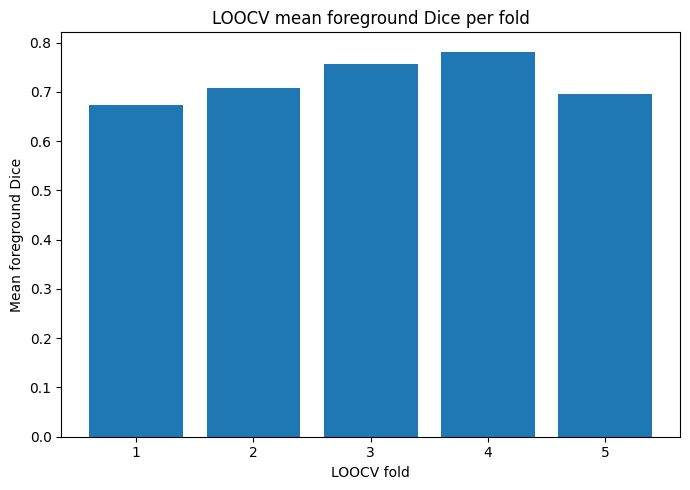

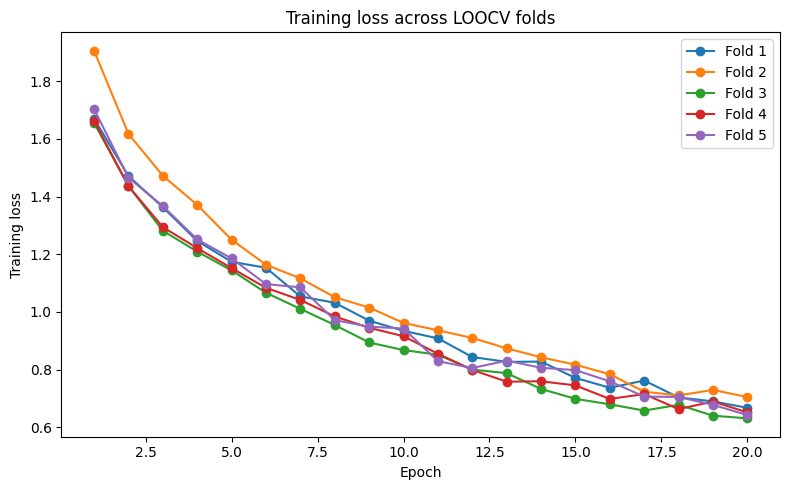

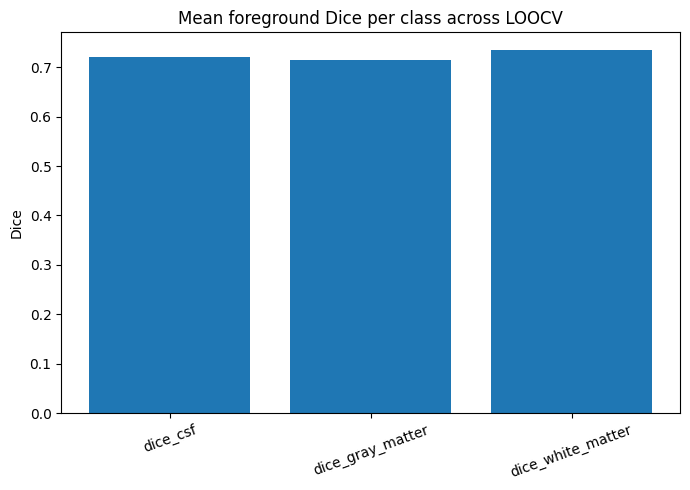

In [26]:
# LOOCV summary tables and plots.
loocv_summary = loocv_results[
    [
        "dice_background",
        "dice_csf",
        "dice_gray_matter",
        "dice_white_matter",
        "mean_foreground_dice",
    ]
].mean(numeric_only=True)

loocv_summary.to_csv(RESULTS / "loocv_summary_mean_scores.csv")

print("LOOCV mean scores:")
display(loocv_summary)

plt.figure(figsize=(7, 5))
plt.bar(
    loocv_results["fold"].astype(str),
    loocv_results["mean_foreground_dice"],
)
plt.xlabel("LOOCV fold")
plt.ylabel("Mean foreground Dice")
plt.title("LOOCV mean foreground Dice per fold")
plt.tight_layout()
plt.savefig(FIGS / "loocv_mean_foreground_dice_per_fold.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))

for fold in sorted(loocv_losses["fold"].unique()):
    sub = loocv_losses[loocv_losses["fold"] == fold]
    plt.plot(sub["epoch"], sub["train_loss"], marker="o", label=f"Fold {fold}")

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss across LOOCV folds")
plt.legend()
plt.tight_layout()
plt.savefig(FIGS / "loocv_training_loss_all_folds.png", dpi=200)
plt.show()

class_scores = loocv_results[
    ["dice_csf", "dice_gray_matter", "dice_white_matter"]
].mean()

plt.figure(figsize=(7, 5))
plt.bar(class_scores.index, class_scores.values)
plt.ylabel("Dice")
plt.title("Mean foreground Dice per class across LOOCV")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGS / "loocv_mean_dice_per_class.png", dpi=200)
plt.show()

In [27]:
final_model, final_loss_df = train_model(
    run_name="final_model_all_5_training_subjects",
    train_subjects=subjects,
    epochs=EPOCHS_FINAL,
    patches_per_subject=PATCHES_PER_SUBJECT,
    loss_mode="dice_ce",
    augment=True,
    foreground_sampling=True,
)

display(final_loss_df)


RUN: final_model_all_5_training_subjects
Train subjects: ['train_1', 'train_2', 'train_3', 'train_4', 'train_5']
Epochs: 20
Loss: dice_ce
Augment: True
Foreground sampling: True
Loaded train_1 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_2 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_3 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_4 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_5 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]


final_model_all_5_training_subjects epoch 1/20: 100%|██████████| 200/200 [00:26<00:00,  7.59it/s, loss=1.3944]


epoch 1/20, train_loss=1.744830


final_model_all_5_training_subjects epoch 2/20: 100%|██████████| 200/200 [00:26<00:00,  7.61it/s, loss=1.5433]


epoch 2/20, train_loss=1.482023


...

final_model_all_5_training_subjects epoch 19/20: 100%|██████████| 200/200 [00:26<00:00,  7.58it/s, loss=0.5339]


epoch 19/20, train_loss=0.620322


final_model_all_5_training_subjects epoch 20/20: 100%|██████████| 200/200 [00:25<00:00,  7.70it/s, loss=0.5636]


epoch 20/20, train_loss=0.608536


,run_name,epoch,train_loss
0,final_model_all_5_training_subjects,1,1.744830
1,final_model_all_5_training_subjects,2,1.482023
2,final_model_all_5_training_subjects,3,1.312089
3,final_model_all_5_training_subjects,4,1.218086
4,final_model_all_5_training_subjects,5,1.142275
5,final_model_all_5_training_subjects,6,1.039239
6,final_model_all_5_training_subjects,7,0.984049
7,final_model_all_5_training_subjects,8,0.979479
8,final_model_all_5_training_subjects,9,0.885845
9,final_model_all_5_training_subjects,10,0.862961


In [28]:
test_results = evaluate_model_on_subjects(
    final_model,
    test_subjects,
    split_name="test_generalisation",
    save_figures=True,
)

test_results.to_csv(RESULTS / "test_generalisation_results.csv", index=False)

display(test_results)

,split,subject,dice_background,dice_csf,dice_gray_matter,dice_white_matter,mean_foreground_dice
0,test_generalisation,test_1,0.971578,0.692152,0.771626,0.812453,0.758744
1,test_generalisation,test_2,0.976994,0.774435,0.772573,0.769887,0.772298
2,test_generalisation,test_3,0.979177,0.770600,0.778437,0.779764,0.776267
3,test_generalisation,test_4,0.978031,0.711401,0.768214,0.788063,0.755893
4,test_generalisation,test_5,0.975993,0.796182,0.775629,0.786032,0.785948
5,test_generalisation,test_6,0.979367,0.808413,0.783547,0.817935,0.803298
6,test_generalisation,test_7,0.976389,0.780229,0.767464,0.784770,0.777488
7,test_generalisation,test_8,0.974815,0.831009,0.768120,0.788554,0.795894
8,test_generalisation,test_9,0.979266,0.828300,0.779492,0.839975,0.815922
9,test_generalisation,test_10,0.976804,0.713809,0.783257,0.803111,0.766726


Test generalisation mean scores:


dice_background         0.976175
dice_csf                0.771336
dice_gray_matter        0.770565
dice_white_matter       0.795241
mean_foreground_dice    0.779047
dtype: float64

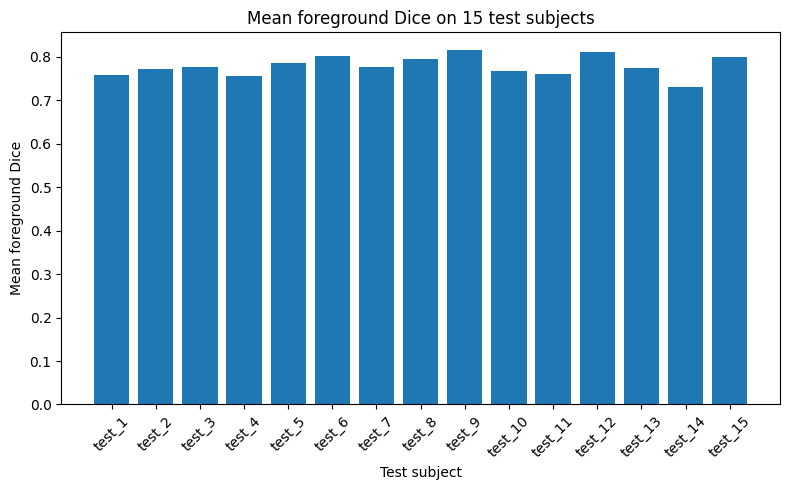

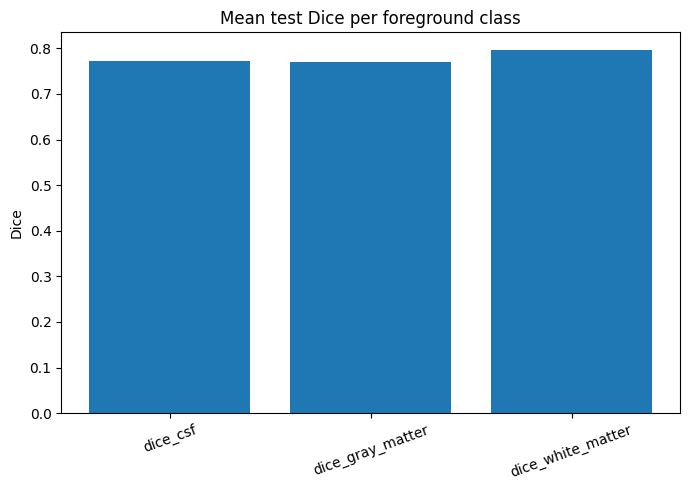

In [29]:
test_summary = test_results[
    [
        "dice_background",
        "dice_csf",
        "dice_gray_matter",
        "dice_white_matter",
        "mean_foreground_dice",
    ]
].mean(numeric_only=True)

test_summary.to_csv(RESULTS / "test_generalisation_summary_mean_scores.csv")

print("Test generalisation mean scores:")
display(test_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    test_results["subject"],
    test_results["mean_foreground_dice"],
)
plt.xlabel("Test subject")
plt.ylabel("Mean foreground Dice")
plt.title("Mean foreground Dice on 15 test subjects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGS / "test_mean_foreground_dice_per_subject.png", dpi=200)
plt.show()

test_class_scores = test_results[
    ["dice_csf", "dice_gray_matter", "dice_white_matter"]
].mean()

plt.figure(figsize=(7, 5))
plt.bar(test_class_scores.index, test_class_scores.values)
plt.ylabel("Dice")
plt.title("Mean test Dice per foreground class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGS / "test_mean_dice_per_class.png", dpi=200)
plt.show()

In [30]:
run_summary = {
    "dataset": "MRBrainS13",
    "training_subjects": [s["id"] for s in subjects],
    "test_subjects": [s["id"] for s in test_subjects],
    "input_modalities": ["T1.nii", "T1_IR.nii", "T2_FLAIR.nii"],
    "target_label": "LabelsForTesting.nii",
    "classes": {
        "0": "background",
        "1": "CSF including ventricles",
        "2": "gray matter including basal ganglia",
        "3": "white matter including lesions",
    },
    "model": "3D U-Net",
    "patch_size": PATCH_SIZE,
    "batch_size": BATCH_SIZE,
    "base_channels": BASE_CHANNELS,
    "learning_rate": LR,
    "loocv_epochs": EPOCHS_LOOCV,
    "final_epochs": EPOCHS_FINAL,
    "patches_per_subject": PATCHES_PER_SUBJECT,
    "loss_main": "Dice + Cross Entropy",
    "augmentation": True,
    "foreground_sampling": True,
    "loocv_mean_scores": loocv_summary.to_dict(),
    "test_mean_scores": test_summary.to_dict(),
}

with open(RESULTS / "run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

with open(LOGS / "run_summary.txt", "w") as f:
    f.write(json.dumps(run_summary, indent=2))

print(json.dumps(run_summary, indent=2))

{
  "dataset": "MRBrainS13",
  "training_subjects": [
    "train_1",
    "train_2",
    "train_3",
    "train_4",
    "train_5"
  ],
  "test_subjects": [
    "test_1",
    "test_2",
    "test_3",
    "test_4",
    "test_5",
    "test_6",
    "test_7",
    "test_8",
    "test_9",
    "test_10",
    "test_11",
    "test_12",
    "test_13",
    "test_14",
    "test_15"
  ],
  "input_modalities": [
    "T1.nii",
    "T1_IR.nii",
    "T2_FLAIR.nii"
  ],
  "target_label": "LabelsForTesting.nii",
  "classes": {
    "0": "background",
    "1": "CSF including ventricles",
    "2": "gray matter including basal ganglia",
    "3": "white matter including lesions"
  },
  "model": "3D U-Net",
  "patch_size": [
    64,
    64,
    32
  ],
  "batch_size": 1,
  "base_channels": 16,
  "learning_rate": 0.0001,
  "loocv_epochs": 20,
  "final_epochs": 20,
  "patches_per_subject": 40,
  "loss_main": "Dice + Cross Entropy",
  "augmentation": true,
  "foreground_sampling": true,
  "loocv_mean_scores": {
    "

In [31]:
 EPOCHS_FINAL_EXTRA = 40

final_model_extra, final_loss_extra = train_model(
    run_name="final_model_all_5_training_subjects_40epochs",
    train_subjects=subjects,
    epochs=EPOCHS_FINAL_EXTRA,
    patches_per_subject=PATCHES_PER_SUBJECT,
    loss_mode="dice_ce",
    augment=True,
    foreground_sampling=True,
)

extra_test_results = evaluate_model_on_subjects(
    final_model_extra,
    test_subjects,
    split_name="test_generalisation_40epochs",
    save_figures=True,
)

extra_test_results.to_csv(RESULTS / "test_generalisation_40epochs_results.csv", index=False)

extra_test_summary = extra_test_results[
    [
        "dice_background",
        "dice_csf",
        "dice_gray_matter",
        "dice_white_matter",
        "mean_foreground_dice",
    ]
].mean(numeric_only=True)

extra_test_summary.to_csv(RESULTS / "test_generalisation_40epochs_summary_mean_scores.csv")

print("40-epoch test summary:")
display(extra_test_summary)


RUN: final_model_all_5_training_subjects_40epochs
Train subjects: ['train_1', 'train_2', 'train_3', 'train_4', 'train_5']
Epochs: 40
Loss: dice_ce
Augment: True
Foreground sampling: True
Loaded train_1 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_2 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_3 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_4 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]
Loaded train_5 image (3, 240, 240, 48) label (240, 240, 48) labels [0 1 2 3]


final_model_all_5_training_subjects_40epochs epoch 1/40: 100%|██████████| 200/200 [00:26<00:00,  7.54it/s, loss=1.2948]


epoch 1/40, train_loss=1.582780


final_model_all_5_training_subjects_40epochs epoch 2/40: 100%|██████████| 200/200 [00:26<00:00,  7.64it/s, loss=1.2012]


epoch 2/40, train_loss=1.324731


...

final_model_all_5_training_subjects_40epochs epoch 39/40: 100%|██████████| 200/200 [00:26<00:00,  7.50it/s, loss=0.4200]


epoch 39/40, train_loss=0.460297


final_model_all_5_training_subjects_40epochs epoch 40/40: 100%|██████████| 200/200 [00:26<00:00,  7.49it/s, loss=0.4299]


epoch 40/40, train_loss=0.453517
40-epoch test summary:


dice_background         0.980166
dice_csf                0.796782
dice_gray_matter        0.778713
dice_white_matter       0.806367
mean_foreground_dice    0.793954
dtype: float64

Loaded ablation: /home/jovyan/outputs/results/ablation_summary.csv
Loaded loocv: /home/jovyan/outputs/results/loocv_results.csv
Loaded loocv_summary: /home/jovyan/outputs/results/loocv_summary_mean_scores.csv
Loaded test20: /home/jovyan/outputs/results/test_generalisation_summary_mean_scores.csv
Loaded test40: /home/jovyan/outputs/results/test_generalisation_40epochs_summary_mean_scores.csv
Loaded final20vs40: /home/jovyan/outputs/results/final_model_20_vs_40_epoch_comparison.csv


,comparison_group,method,dice_csf,dice_gray_matter,dice_white_matter,mean_foreground_dice,what_this_tests
0,Fold-1 ablation,baseline_dice_no_aug,0.5229,0.2495,0.1928,0.3217,Effect of improved training strategy vs baseline
1,Fold-1 ablation,improved_dice_ce_aug,0.5951,0.4180,0.7473,0.5868,Effect of improved training strategy vs baseline
2,5-fold LOOCV,"Improved method, mean over 5 held-out subjects",0.7210,0.7151,0.7338,0.7233,Main validation/generalisation across 5 traini...
3,Final model training duration,20_epoch_final,0.7713,0.7706,0.7952,0.7790,Effect of training final model for longer
4,Final model training duration,40_epoch_final,0.7968,0.7787,0.8064,0.7940,Effect of training final model for longer


LOOCV fold-by-fold table:


,fold,subject,dice_csf,dice_gray_matter,dice_white_matter,mean_foreground_dice
0,1,train_1,0.7012,0.6382,0.6812,0.6735
1,2,train_2,0.7146,0.7463,0.6657,0.7089
2,3,train_3,0.7679,0.6822,0.8199,0.7567
3,4,train_4,0.7642,0.7491,0.8328,0.7820
4,5,train_5,0.6568,0.7597,0.6695,0.6953


Baseline vs improved gain table:


,metric,baseline,improved,absolute_change
0,CSF Dice,0.5229,0.5951,0.0722
1,Gray matter Dice,0.2495,0.4180,0.1685
2,White matter Dice,0.1928,0.7473,0.5545
3,Mean foreground Dice,0.3217,0.5868,0.2651


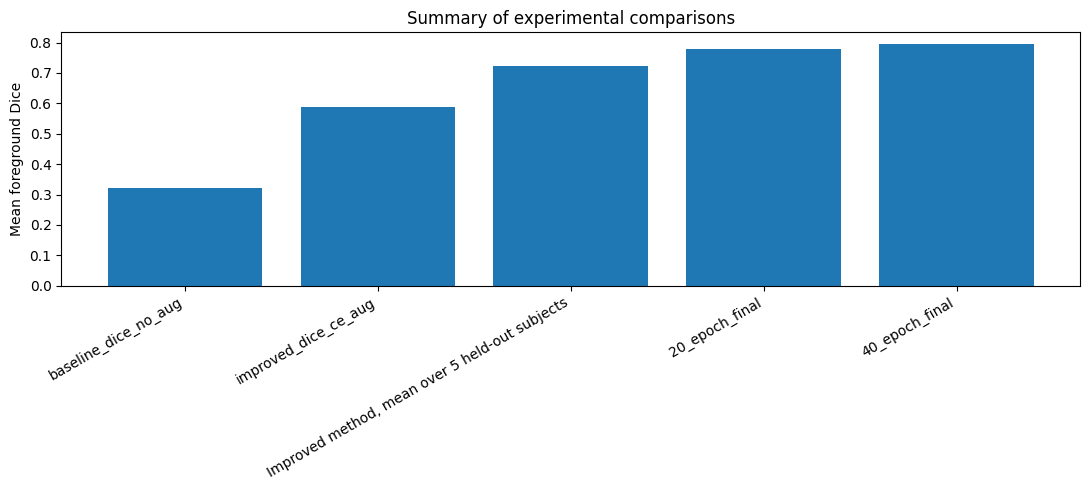

Saved:
/home/jovyan/outputs/results/all_comparisons_summary_table.csv
/home/jovyan/outputs/results/loocv_report_table.csv
/home/jovyan/outputs/results/baseline_vs_improved_gain_table.csv
/home/jovyan/outputs/figures/all_comparisons_mean_foreground_dice.png


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path("/home/jovyan/outputs/results")
FIGS = Path("/home/jovyan/outputs/figures")

# ----------------------------
# Load available result files
# ----------------------------
tables = {}

files = {
    "ablation": RESULTS / "ablation_summary.csv",
    "loocv": RESULTS / "loocv_results.csv",
    "loocv_summary": RESULTS / "loocv_summary_mean_scores.csv",
    "test20": RESULTS / "test_generalisation_summary_mean_scores.csv",
    "test40": RESULTS / "test_generalisation_40epochs_summary_mean_scores.csv",
    "final20vs40": RESULTS / "final_model_20_vs_40_epoch_comparison.csv",
}

for name, path in files.items():
    if path.exists():
        tables[name] = pd.read_csv(path)
        print(f"Loaded {name}: {path}")
    else:
        print(f"Missing {name}: {path}")

# ----------------------------
# Table 1: Main comparison summary
# ----------------------------
summary_rows = []

# Baseline/improved ablation if available
if "ablation" in tables:
    ab = tables["ablation"].copy()
    for _, row in ab.iterrows():
        summary_rows.append({
            "comparison_group": "Fold-1 ablation",
            "method": row["method"],
            "dice_csf": row["dice_csf"],
            "dice_gray_matter": row["dice_gray_matter"],
            "dice_white_matter": row["dice_white_matter"],
            "mean_foreground_dice": row["mean_foreground_dice"],
            "what_this_tests": "Effect of improved training strategy vs baseline"
        })

# LOOCV mean
if "loocv_summary" in tables:
    ls = tables["loocv_summary"]
    
    # Handles both possible CSV formats
    if "Unnamed: 0" in ls.columns:
        vals = dict(zip(ls["Unnamed: 0"], ls.iloc[:, 1]))
    else:
        vals = ls.iloc[:, 0].to_dict()
    
    summary_rows.append({
        "comparison_group": "5-fold LOOCV",
        "method": "Improved method, mean over 5 held-out subjects",
        "dice_csf": vals.get("dice_csf", np.nan),
        "dice_gray_matter": vals.get("dice_gray_matter", np.nan),
        "dice_white_matter": vals.get("dice_white_matter", np.nan),
        "mean_foreground_dice": vals.get("mean_foreground_dice", np.nan),
        "what_this_tests": "Main validation/generalisation across 5 training subjects"
    })

# 20 vs 40 final model
if "final20vs40" in tables:
    comp = tables["final20vs40"].copy()
    for _, row in comp.iterrows():
        summary_rows.append({
            "comparison_group": "Final model training duration",
            "method": row["model"],
            "dice_csf": row["dice_csf"],
            "dice_gray_matter": row["dice_gray_matter"],
            "dice_white_matter": row["dice_white_matter"],
            "mean_foreground_dice": row["mean_foreground_dice"],
            "what_this_tests": "Effect of training final model for longer"
        })
else:
    if "test20" in tables:
        ts = tables["test20"]
        vals = dict(zip(ts.iloc[:, 0], ts.iloc[:, 1])) if ts.shape[1] >= 2 else {}
        summary_rows.append({
            "comparison_group": "Final model training duration",
            "method": "20_epoch_final",
            "dice_csf": vals.get("dice_csf", np.nan),
            "dice_gray_matter": vals.get("dice_gray_matter", np.nan),
            "dice_white_matter": vals.get("dice_white_matter", np.nan),
            "mean_foreground_dice": vals.get("mean_foreground_dice", np.nan),
            "what_this_tests": "20-epoch final model on 15 test subjects"
        })

    if "test40" in tables:
        ts = tables["test40"]
        vals = dict(zip(ts.iloc[:, 0], ts.iloc[:, 1])) if ts.shape[1] >= 2 else {}
        summary_rows.append({
            "comparison_group": "Final model training duration",
            "method": "40_epoch_final",
            "dice_csf": vals.get("dice_csf", np.nan),
            "dice_gray_matter": vals.get("dice_gray_matter", np.nan),
            "dice_white_matter": vals.get("dice_white_matter", np.nan),
            "mean_foreground_dice": vals.get("mean_foreground_dice", np.nan),
            "what_this_tests": "40-epoch final model on 15 test subjects"
        })

comparison_summary = pd.DataFrame(summary_rows)

comparison_summary = comparison_summary.round({
    "dice_csf": 4,
    "dice_gray_matter": 4,
    "dice_white_matter": 4,
    "mean_foreground_dice": 4,
})

comparison_summary.to_csv(RESULTS / "all_comparisons_summary_table.csv", index=False)

display(comparison_summary)

# ----------------------------
# Table 2: LOOCV fold-by-fold table
# ----------------------------
if "loocv" in tables:
    loocv_table = tables["loocv"][
        [
            "fold",
            "subject",
            "dice_csf",
            "dice_gray_matter",
            "dice_white_matter",
            "mean_foreground_dice",
        ]
    ].copy()

    loocv_table = loocv_table.round(4)
    loocv_table.to_csv(RESULTS / "loocv_report_table.csv", index=False)

    print("LOOCV fold-by-fold table:")
    display(loocv_table)

# ----------------------------
# Add improvement columns for baseline vs improved
# ----------------------------
if "ablation" in tables:
    ab = tables["ablation"].copy()

    if len(ab) >= 2:
        baseline = ab.iloc[0]
        improved = ab.iloc[1]

        improvement = pd.DataFrame([
            {
                "metric": "CSF Dice",
                "baseline": baseline["dice_csf"],
                "improved": improved["dice_csf"],
                "absolute_change": improved["dice_csf"] - baseline["dice_csf"],
            },
            {
                "metric": "Gray matter Dice",
                "baseline": baseline["dice_gray_matter"],
                "improved": improved["dice_gray_matter"],
                "absolute_change": improved["dice_gray_matter"] - baseline["dice_gray_matter"],
            },
            {
                "metric": "White matter Dice",
                "baseline": baseline["dice_white_matter"],
                "improved": improved["dice_white_matter"],
                "absolute_change": improved["dice_white_matter"] - baseline["dice_white_matter"],
            },
            {
                "metric": "Mean foreground Dice",
                "baseline": baseline["mean_foreground_dice"],
                "improved": improved["mean_foreground_dice"],
                "absolute_change": improved["mean_foreground_dice"] - baseline["mean_foreground_dice"],
            },
        ])

        improvement = improvement.round(4)
        improvement.to_csv(RESULTS / "baseline_vs_improved_gain_table.csv", index=False)

        print("Baseline vs improved gain table:")
        display(improvement)

# ----------------------------
# Plot: all comparison mean foreground Dice
# ----------------------------
plot_df = comparison_summary.dropna(subset=["mean_foreground_dice"]).copy()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["method"], plot_df["mean_foreground_dice"])
plt.ylabel("Mean foreground Dice")
plt.title("Summary of experimental comparisons")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGS / "all_comparisons_mean_foreground_dice.png", dpi=200)
plt.show()

print("Saved:")
print(RESULTS / "all_comparisons_summary_table.csv")
print(RESULTS / "loocv_report_table.csv")
print(RESULTS / "baseline_vs_improved_gain_table.csv")
print(FIGS / "all_comparisons_mean_foreground_dice.png")